# 第8回　前処理と Pipeline
***
> **前提**: 第5回（タイタニック）で学んだ前処理を発展させます。第5回は `dropna` で欠損を除去しましたが、本回は**補完**と **Pipeline** で自動化します。

> ⚠️ **この課題で身につけること：コーディングではなく「AI（機械学習）の中身の理解」です。**
>
> コードは AI に書かせても構いません。重要なのは「**なぜその処理を選ぶのか**」「**パラメータや特徴量を変えると結果がどう変わるのか**」を理解し、提出物で示すことです。各問には学習目標を示すタグが付いています。
>
> | タグ | 意味 | あなたがすること |
> |---|---|---|
> | **【骨格】** | 動くコードは与えられている | 設計上の決定点（数値・選択肢・特徴量）だけを変更する |
> | **【選択】** | 適切な手法を選ぶ問題 | 複数候補から選び、**理由**を解答用コードセルに書く |
> | **【実験】** | 試行錯誤の記録 | パラメータ等を変えて結果を表に記録し、**考察**する |
> | **【説明】** | 理解の証跡 | 与えられたコードの各行に `# 説明:` で意味を書く |
>
> コードは原則として完成形ですが、**各問の「核心となる最低限の数行」は `# ★あなたが書く★` として空欄**にしてあります。AI に頼り切らず、要となる処理は自分で書けることも確認します（ボイラープレートは提供済み）。
>
> 各問の **✍️ 解答用コードセル**（`# (1-a)` 形式の変数・文字列）に、設計判断・理由・実験結果・考察を**項目ごとに**記入してください。これが採点対象です。

## 目次
1. データの読み込み
2. 欠損値の確認と補完
3. ColumnTransformer と Pipeline
4. モデル評価

---

## この回で学ぶこと

### なぜ前処理が重要なのか

現実のデータは必ず「汚れている」。欠損値・外れ値・スケールの違いを放置したままモデルを学習させると，精度が著しく落ちたり，最悪の場合モデルが全く機能しない。前処理はデータサイエンスの作業時間の **60〜80%** を占めると言われており，卒業研究でも避けられないスキルだ。

### 欠損値補完（Imputation）

欠損値の扱いには大きく3つの方針がある：

| 方針 | 方法 | いつ使うか |
|---|---|---|
| 削除 | `dropna()` | 欠損が全体の5%未満，かつランダムに欠損している場合 |
| 統計値で補完 | `SimpleImputer` | 欠損が多く削除できない場合（本回） |
| モデルで予測補完 | `IterativeImputer` など | 欠損パターンに意味がある場合（発展） |

`SimpleImputer` の `strategy` の違い：
- `"mean"` : 外れ値の影響を受けやすい。正規分布に近いデータに向く
- `"median"` : 外れ値に強い。**右に歪んだデータに推奨**
- `"most_frequent"` : カテゴリ変数や欠損率が低い数値列に向く

### スケーリング（正規化・標準化）— 列ごとに「数字の大きさ」が違う問題

第5回と同じタイタニックデータでは，数値列の**桁**がバラバラです（問題1でも同じ7列を使います）。

| 列 | だいたいの範囲 | 意味のイメージ |
|---|---|---|
| `Pclass` | 1〜3 | 客室クラス（数字が小さいほど上等） |
| `Age` | 0〜80 歳前後 | 年齢 |
| `Fare` | 0〜500 前後 | 運賃（最大値が `Pclass` よりずっと大きい） |

**なぜ気にするか**：一部のモデルは「数値の大小そのもの」で比較します。`Fare` が 200・`Pclass` が 2 のとき，モデルが「200 と 2 の差の大きさ」をそのまま見ると，**運賃の方が圧倒的に重要そうに見える**ことがあります。スケーリングは，各列のスケールを揃えて，**列同士を公平に比較しやすくする**前処理です。

| 手法 | ざっくりした変換 | 特徴 |
|---|---|---|
| `StandardScaler` | 平均0・ばらつき1くらいにそろえる | 外れ値があっても比較的安定 |
| `MinMaxScaler` | 最小0・最大1に押し込む | 0〜1 に揃う。外れ値に弱い |

**今回のモデル（決定木）について**：決定木は「`Age` は 25 より大きいか？」のように**しきい値で枝分かれ**します。`Fare` を 0〜1 に縮めても，「しきい値の位置」は本質的に同じような分け方になるため，**スケーラを変えても正解率はほとんど変わらない**はずです（問題2の考察2で確認）。それでも本回は `StandardScaler` / `MinMaxScaler` を Pipeline に入れて，**前処理の流れを組み立てる練習**をします。

### Pipeline の本当の価値：データリーク防止

Pipeline を使わずに手動で `fit_transform` すると，テストデータの情報が訓練データの統計量に混入する「**データリーク（Data Leakage）**」が起きる危険がある。

```
【NG例：データリーク】
scaler.fit_transform(X_all)  # テストデータの情報も含めて統計量を計算 → NG
X_train, X_test = split(X_all_scaled)

【OK例：Pipeline】
pipeline.fit(X_train, y_train)   # 訓練データだけで統計量を計算
pipeline.predict(X_test)          # 訓練データの統計量でテストデータを変換 → OK
```

卒業研究で「時系列データの未来情報が混入してモデルが異常に高精度になった」という失敗はよく起こる。Pipeline はこれを防ぐ設計思想だ。

---

## 📚 将来の自分のためのメモ — 大学研究での応用


### どんな研究で使われるか

| 分野 | 具体例 |
|---|---|
| 医学・公衆衛生 | 患者データの欠損補完，検査値の標準化，予後予測の前処理パイプライン |
| 社会学・経済学 | アンケート・行政データ（欠損・カテゴリ混在）の再現可能な前処理 |
| 心理学・教育学 | 縦断調査データで，訓練/検証分割後にのみ統計量を計算する設計 |
| 情報科学 | 表形式データの機械学習実験全般（Kaggle でも Pipeline は標準） |

### 応用できる場面

- **表形式データ**（CSV，データベース）で，数値列とカテゴリ列が混在している
- 欠損値があり，「削除するとサンプルが足りなくなる」場合
- **再現性**が求められる（論文・卒論で「同じ手順を他者が再実行できる」必要がある）
- `train_test_split` の**後**に前処理を行い，**データリークを防ぎたい**とき（本回の Pipeline の本質）

### 応用しにくい・向かない場面

- **生画像・生テキスト**：`ColumnTransformer` ではなく，畳み込みやトークナイズなど別の前処理が必要（第14回以降）
- **時系列データ**：単純なランダム分割は未来情報のリークになりうる。時系列用の分割（`TimeSeriesSplit` など）が別途必要
- **因果推論**：「どの変数が原因か」を Pipeline だけでは答えられない（相関と因果は別問題）
- **データがきれいで少ない**：前処理の選択肢を比較する余地が小さく，本格的な実験設計の練習にはなりにくい

### 研究で報告するときのポイント

1. **前処理の手順を論文に書く**（補完方法，スケーラ，カテゴリの符号化）— 再現性のため
2. **どのデータで統計量を計算したか**を明記（訓練のみ vs 全体）— リーク防止の証明
3. 前処理の違いが結果に与える影響を示すと，査読で信頼されやすい

### 関連する発展トピック（調べてみると良い）

- `IterativeImputer`（多変量による欠損補完）
- `Feature-engine` や `sklearn-pandas`（複雑な前処理の自動化）
- MLOps における「学習パイプラインと推論パイプラインの一致」（第17回の Distribution Shift とつながる）


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

import pandas as pd

TITANIC_URL = "https://raw.githubusercontent.com/ShotaYmzk/AI-kadai/main/data/titanic/titanic.csv"

def load_titanic() -> pd.DataFrame:
    return pd.read_csv(TITANIC_URL)


## 問題1　データの読み込みと欠損確認　【骨格+選択】
***

### 背景

分析を始める前に必ず「データの全体像を把握する」ことが重要。列の型・サンプル数・欠損数を確認しないまま進めると，後で予期しないエラーや誤った分析に繋がる。これは研究でも実務でも最初に必ずやるべきステップです。

各列の意味：
- `Survived` : 生存フラグ（0=死亡, 1=生存）→ **予測したい目的変数**
- `Pclass` : 客室クラス（1=一等, 2=二等, 3=三等）→ 社会的地位の代理変数
- `Sex` : 性別（male/female）→ カテゴリ変数なので後でエンコードが必要
- `Age` : 年齢 → **欠損が多い列（約20%）**
- `SibSp` / `Parch` : 同乗する兄弟姉妹数 / 親子数
- `Fare` : 運賃 → 右に裾が長い分布（外れ値あり）

### 課題

読み込みとヒストグラム描画は用意してあります。**核心の1行（各列の欠損数を求める処理）だけ自分で書いて**（`# ★あなたが書く★`）からセルを実行し、出力を観察してください。

観察したうえで、次の **設計判断** に答え、**解答用コードセル**に記入してください。

> **設計判断1**: `Age` 列は約20%が欠損しています。この欠損をどう扱うべきか、次の選択肢から**1つ選び、理由**を解答用コードセルに書いてください。ここでの選択は問題2の補完方法にそのまま使います。
>
> - **(A) 行ごと削除（`dropna`）** … 欠損行を捨てる
> - **(B) 平均値で補完（`mean`）**
> - **(C) 中央値で補完（`median`）**
> - **(D) 最頻値で補完（`most_frequent`）**
> - **(E) 定数（例: 0）で補完** … 欠損であること自体を一つの値とみなす
> - **(F) 他の特徴量から予測して補完（`IterativeImputer` など）** … Pclass や Fare から Age を推定
>
> ヒント：**欠損率% の Age 行**を (1-a) に書く。(1-b) の「歪み」は下の**参考図**と，実データのヒストグラム・歪度で判断する。「正解は1つ」ではなく，**根拠が筋の通った選択**が重要。(E)(F) のデメリットも考えると説得力が増す。

### 参考：分布の「歪み」の見え方（下のセルを実行）

「**山（峰）がどちらにあるか**」ではなく，「**どちら側に長い裾（少数の極端な値）があるか**」で左右を決める。

| 呼び方 | 裾の向き | 歪度の目安 | イメージ |
|---|---|---|---|
| 左右対称 | 左右とも短い | 0 に近い | 正規分布のような形 |
| **右に歪む** | **右側**に裾 | **正（>0）** | 若年に山があり，高齢側に少数がのびる |
| 左に歪む | 左側に裾 | 負（<0） | 高齢に山があり，若年側に少数がのびる |

よくある誤解：「グラフの左に山がある＝左に歪む」ではない。


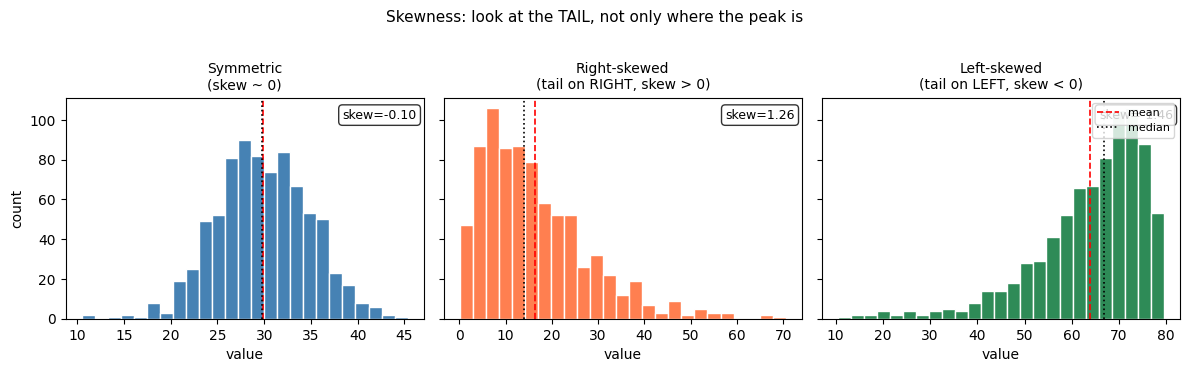

Age (Titanic) はこの中のどれかに似ているはずです。


In [11]:
# === 参考図：分布の歪み（実行するだけ。記入不要）===
rng = np.random.default_rng(0)

symmetric = rng.normal(30, 5, 800)
right_skew = rng.gamma(shape=2.0, scale=8.0, size=800)   # 左に山・右に裾（Age に近いイメージ）
left_skew = 80 - rng.gamma(shape=2.0, scale=8.0, size=800)  # 右に山・左に裾

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
examples = [
    (symmetric, "Symmetric\n(skew ~ 0)", "steelblue"),
    (right_skew, "Right-skewed\n(tail on RIGHT, skew > 0)", "coral"),
    (left_skew, "Left-skewed\n(tail on LEFT, skew < 0)", "seagreen"),
]

for ax, (data, title, color) in zip(axes, examples):
    ax.hist(data, bins=25, color=color, edgecolor="white")
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=1.2, label="mean")
    ax.axvline(np.median(data), color="black", linestyle=":", linewidth=1.2, label="median")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("value")
    skew_val = pd.Series(data).skew()
    ax.text(0.98, 0.95, f"skew={skew_val:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

axes[0].set_ylabel("count")
axes[2].legend(loc="upper right", fontsize=8)
fig.suptitle("Skewness: look at the TAIL, not only where the peak is", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print("Age (Titanic) はこの中のどれかに似ているはずです。")


In [ ]:
# === 用意済み：データの読み込み ===
USE_COLS = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
df_titanic = load_titanic()[USE_COLS].copy()

print("形式 (行数, 列数):", df_titanic.shape)
df_titanic.info()

# ★あなたが書く★：各列の「欠損数」を求めて missing に代入する（1行）
#   ヒント: DataFrame には欠損を数えるメソッドがある（isnull / isna と sum の組み合わせ）
missing =  # ★ここに1行: 各列の欠損数★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
if missing is None:
    raise NotImplementedError("欠損数を求める1行を書いてから再実行してください")

# === 用意済み：欠損率の計算と表示 ===
missing_rate = (missing / len(df_titanic) * 100).round(1)
print("\n各列の欠損数 / 欠損率(%):")
print(pd.concat([missing.rename("欠損数"), missing_rate.rename("欠損率%")], axis=1))

# Age の分布（参考図の「右に歪む」に近いか確認 → (1-b) の根拠）
# 山が若年側（左）でも高齢側に裾があれば右に歪む（歪度>0）
df_titanic["Age"].hist(bins=30)
plt.title("Age の分布")
plt.xlabel("Age")
plt.ylabel("ppl")
plt.show()
print("歪度（正なら右に歪む）:", round(df_titanic["Age"].skew(), 3))


In [ ]:
# === ✍️ 問題1 解答（採点対象）===

# (1-a) 観察：Age 列の欠損率（%）— 上のセル出力の Age 行から記入
age_missing_pct = ""

# (1-b) 観察：ヒストグラムの形（"左右対称" / "右に歪む" / "左に歪む"）
age_distribution = ""

# (1-c) 設計判断1：次から1つ選び、字母1文字を入れる（例: "C"）
# (A) 行ごと削除（dropna）… 欠損行を捨てる
# (B) 平均値で補完（mean）
# (C) 中央値で補完（median）
# (D) 最頻値で補完（most_frequent）
# (E) 定数（例: 0）で補完 … 欠損であること自体を一つの値とみなす
# (F) 他の特徴量から予測して補完（IterativeImputer など）… Pclass や Fare から Age を推定
design1_choice = ""

# (1-d) その理由（(1-a)(1-b) を根拠に）
design1_reason = """
"""

# (1-e) 選ばなかった理由
design1_rejected = """
"""


## 問題2　補完方法とスケーラの実験　【実験】
***

### なぜ中央値を使うのか

`Age` 列の分布は右に歪んでいる（若者が多く，高齢者が少ない）。山が若年側（左）にあっても、**高齢側に裾が伸びていれば統計上は右に歪む**（歪度>0）。問題1で「左に歪む」と書いた場合は，参考図と実データのヒストグラムを見直してください。このような分布では：
- **平均値（mean）** は外れ値（100歳超など）に引っ張られて実態より高くなる
- **中央値（median）** は順位に基づくため，外れ値の影響を受けない

> **研究での判断基準**: ヒストグラムや箱ひげ図で分布の歪みを確認してから補完方法を選ぼう。`df["Age"].hist()` で確認できる。

### `fit` と `transform` の分離が重要な理由

```python
imputer.fit(X_train)      # 訓練データから中央値を「学習」
imputer.transform(X_test) # 学習した中央値でテストデータを変換
```

`fit_transform(X_all)` を全データに使うと，テストデータの値も中央値の計算に含まれる（データリーク）。**下の実験コードでは `pipe.fit(X_train, y_train)` とし，補完・スケーリングの統計量は訓練データだけから学習します**（問題3の Pipeline がその仕組み）。第10回では手動前処理の落とし穴も対比して学びます。

### 課題

下のコードセルには、前処理＋モデルをまとめた **`build_pipeline(imputer_strategy, scaler_name)` が用意**されています（中身の解説は問題3で行います）。ただし**実験ループの核心（学習と正解率の計算）はあなたが書きます**（`# ★あなたが書く★`）。

`settings` の組合せを **5通り以上**、しかも **imputer と scaler の両方の軸を動かして**試し、結果（正解率）を **解答用コードセルの `experiment_log`** に記入してください。

| imputer_strategy | scaler_name |
|---|---|
| `"mean"`, `"median"`, `"most_frequent"` | `"standard"`, `"minmax"` |

そのうえで考察してください：

> **考察1**: 問題1で選んだ補完方法は、実験でも実際に良い精度でしたか？ 想定と違った場合、なぜだと思いますか？
>
> **考察2**: 今回のモデル（決定木）では scaler を変えても精度がほとんど変わらないはずです。**なぜ決定木はスケーリングの影響を受けにくいのか**を、解答用コードセルに書いてください。（ヒント：冒頭の「スケーリング」の節。決定木は「`Age` > 25 か？」のような**しきい値での分岐**なので，数値を全体で伸縮しても分け方がほぼ変わらない）


In [ ]:
# === 完成済みコード：build_pipeline の中身の解説は問題3で行います ===
X = df_titanic.drop(columns="Survived")
y = df_titanic["Survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

def build_pipeline(imputer_strategy="median", scaler_name="standard"):
    numeric_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
    categorical_cols = ["Sex"]
    scaler = StandardScaler() if scaler_name == "standard" else MinMaxScaler()
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy=imputer_strategy)),
        ("scaler", scaler),
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ])
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=0)),
    ])

# === ★ここを変えて実験する★：(imputer_strategy, scaler_name) の組合せ（5通り以上・両軸を動かす） ===
settings = [
    ("mean",          "standard"),
    ("median",        "standard"),
    ("most_frequent", "standard"),
    ("median",        "minmax"),
    ("mean",          "minmax"),
    # 必要なら組合せを追加してよい
]

for strategy, scaler_name in settings:
    pipe = build_pipeline(imputer_strategy=strategy, scaler_name=scaler_name)
    # ★あなたが書く★：pipe を訓練データで学習し、テストデータの正解率を acc に求める（2行程度）
    #   ヒント: pipe.fit(...) で学習し、accuracy_score(正解, pipe.predict(...)) で正解率
    
    acc = None  
    if acc is None:
        raise NotImplementedError("学習と正解率の計算を書いてから再実行してください")
    print(f"imputer={strategy:14s} scaler={scaler_name:9s} -> accuracy={acc:.4f}")


In [ ]:
# === ✍️ 問題2 解答（採点対象）===

# (2-a) 実験ログ（5通り以上・imputer と scaler の両軸を動かす）
experiment_log = pd.DataFrame([
    # {"imputer_strategy": "mean", "scaler_name": "standard", "accuracy": 0.0000},
])

# (2-b) 最も良かった組合せ
best_setting = ""

# (2-c) 考察1
reflection1 = """
"""

# (2-d) 考察2
reflection2 = """
"""


## 問題3　Pipeline の中身を説明する　【説明】
***

### ColumnTransformer とは

現実のデータには数値列とカテゴリ列が混在している。それぞれに異なる前処理を適用するのが `ColumnTransformer` だ。

```
【前処理の分岐イメージ】

数値列 (Pclass, Age, SibSp, Parch, Fare)
    → StandardScaler: スケールを揃える（平均0，標準偏差1）

カテゴリ列 (Sex: "male"/"female")
    → OneHotEncoder: 数値に変換（male=1,0 / female=0,1）
    ※ drop_first=True で多重共線性を避けるため片方を削除することも多い
```

### OneHotEncoding が必要な理由

機械学習モデルは文字列（"male", "female"）を直接扱えない。`LabelEncoder` で 0/1 に変換する方法もあるが，「male=0, female=1」という**数値の大小関係**が意味を持ってしまうため，名義尺度には OneHotEncoding が適切だ。

### criterion="entropy" の意味

決定木には分岐基準として `gini`（デフォルト）と `entropy` がある。どちらも「不純度」を測る指標だが：
- `gini` : 計算が速い
- `entropy` : 情報理論に基づく，不均衡クラスにやや強い

実用上は大差ないが，`max_depth=5` で木の深さを制限することが**過学習防止**に効いている（第13回で詳しく学ぶ）。

### 課題

問題2で「ブラックボックス」として使った `build_pipeline` の**中身を開けて理解**します。

下のコードセルは `build_pipeline` の本体です。**各行の `# 説明:` の右に、その行が何をしているかを自分の言葉で書いて**ください（コード自体は変更しないこと）。書き終えたらセルを実行し、エラーなく学習が終わることを確認してください。

説明を書くときは、次の問いを意識してください：

- なぜ数値列とカテゴリ列で**異なる**変換を適用するのか？
- `OneHotEncoder` は `Sex`（"male"/"female"）をどんな数値に変えるのか？ `LabelEncoder` で 0/1 にするのと何が違うのか？
- `Pipeline` でまとめると、`train_test_split` の後に何が起きてもデータリークが防げるのはなぜか？

> **設計判断2（一言で）**: もし `numeric_cols` と `categorical_cols` を**取り違えて**、`Sex` に `StandardScaler`、数値列に `OneHotEncoder` を適用したら何が起きると思いますか？ 解答用コードセルの `(3-d)` に1〜2文で書いてください。


In [ ]:
# 下は build_pipeline の中身です。各行の「# 説明:」に自分の言葉で意味を書いてください。
# （コードは変更しない。説明は AI に書かせず、自分の言葉で書くこと）

numeric_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare"]   # 説明:
categorical_cols = ["Sex"]                                   # 説明:

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),           # 説明:
    ("scaler", StandardScaler()),                            # 説明:
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),              # 説明:
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),  # 説明:
])

model = Pipeline([
    ("preprocess", preprocessor),                            # 説明:
    ("clf", DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=0)),  # 説明:
])

model.fit(X_train, y_train)  # 説明:
print("学習完了。test accuracy =", round(accuracy_score(y_test, model.predict(X_test)), 4))


In [ ]:
# === ✍️ 問題3 解答（採点対象）===
# 主な提出物は上のコードセルへの # 説明: 記入。以下も記入すること。

# (3-a) なぜ数値列とカテゴリ列で異なる変換を適用するのか
answer_3a = """
"""

# (3-b) OneHotEncoder と LabelEncoder の違い
answer_3b = """
"""

# (3-c) Pipeline でデータリークが防げる理由
answer_3c = """
"""

# (3-d) 設計判断2：numeric_cols と categorical_cols を取り違えたら
answer_3d = """
"""


## 問題4　評価指標の選択　【選択+考察】
***

### 正解率（Accuracy）だけで判断してはいけない

正解率はわかりやすい指標だが，**クラスが不均衡な場合に誤解を招く**。例えばタイタニックでは生存者（38%）より死亡者（62%）が多い。「全員死亡」と予測するだけで正解率62%になる。

そのため実際の研究では正解率に加えて以下も確認する：
- **適合率（Precision）**: 「生存と予測した中で本当に生存した割合」
- **再現率（Recall）**: 「実際の生存者の中でモデルが生存と予測した割合」
- **F1スコア**: Precision と Recall の調和平均

（これらは第12回で詳しく扱う。今回は出力された `classification_report` を読み取り、用途に応じて重視すべき指標を選ぶ。）

### Pipeline の predict の動作

`pipeline.predict(X_test)` を呼び出すと，内部で以下が**自動的に**行われる：
1. `ColumnTransformer` でテストデータを変換（StandardScaler は訓練データの μ,σ を使用）
2. 変換後のデータを `DecisionTreeClassifier` に入力して予測

これが Pipeline の強力さだ。手動で変換すると手順を間違えやすいが，Pipeline は常に正しい順序で処理する。

### 課題

下のコードセルは、`classification_report` の出力までは用意してありますが、**核心（モデルの正解率と「全員死亡」ベースラインの計算）はあなたが書きます**（`# ★あなたが書く★`）。書いて実行し、出力を見て次の設計判断に答えてください。

> **設計判断3**: 仮に、このモデルを「**生存できそうな人を見落とさず救命ボートに優先案内する**」用途に使うとします。重視すべき指標を次から選び、**理由**を解答用コードセルに書いてください。
>
> - **(A) Accuracy（正解率）**
> - **(B) Precision（適合率：生存と予測した中で本当に生存した割合）**
> - **(C) Recall（再現率：実際の生存者をどれだけ拾えたか）**
> - **(D) F1（Precision と Recall の調和平均）**
> - **(E) 混同行列を全体で見る（TP/FP/FN/TN を個別に確認）**
> - **(F) ROC-AUC（閾値に依存しない総合的な分離性能）**
>
> ヒント：この用途では「本当は助かる人を死亡と誤判定して案内しない（見逃し=FN）」のと「助からない人を生存と誤判定する（誤報=FP）」の、どちらがより避けたい失敗か？を考える。

> **考察3**: 出力された正解率は「全員死亡ベースライン」をどれだけ上回りましたか？ もし差が小さい場合、それは「モデルが役に立たない」ことを意味するでしょうか、それとも別の見方ができますか？


In [ ]:
# === 用意済み：学習と予測 ===
from sklearn.metrics import classification_report

best_pipe = build_pipeline(imputer_strategy="median", scaler_name="standard")
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

# ★あなたが書く★：モデルの正解率 acc と、全員「死亡(0)」と予測したときの正解率 baseline（各1行）
#   ヒント: acc は accuracy_score(...)。baseline は y_test が 0 である割合 = (y_test == 0).mean()
acc = None  
baseline = None  
if acc is None or baseline is None:
    raise NotImplementedError("acc と baseline を求める1行ずつを書いてから再実行してください")

# === 用意済み：結果表示 ===
print(f"モデルの正解率        : {acc:.4f}")
print(f"全員死亡ベースライン  : {baseline:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["死亡(0)", "生存(1)"]))


In [ ]:
# === ✍️ 問題4 解答（採点対象）===

# (4-a) 仮に、このモデルを「生存できそうな人を見落とさず救命ボートに優先案内する」用途に使うとします。
# 重視すべき指標を次から1つ選び、字母1文字を入れる（例: "C"）
# (A) Accuracy（正解率）
# (B) Precision（適合率：生存と予測した中で本当に生存した割合）
# (C) Recall（再現率：実際の生存者をどれだけ拾えたか）
# (D) F1（Precision と Recall の調和平均）
# (E) 混同行列を全体で見る（TP/FP/FN/TN を個別に確認）
# (F) ROC-AUC（閾値に依存しない総合的な分離性能）
design3_choice = ""

# (4-b) その理由（FN と FP のどちらを避けたいか）
design3_reason = """
"""

# (4-c) 観察：モデルの正解率と全員死亡ベースライン（上のセル出力から）
observed_acc = None
observed_baseline = None

# (4-d) 考察3
reflection3 = """
"""
